In [1]:

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')

import os
import pandas as pd
import librosa 
import numpy as np


# mehrklassen probieren
# loss funktion recherchieren
# verschiedene Window Größen

WINDOW_LENGTH = 1

data = "./features-relative.csv"
signals_folder = "./Spontanaktivität"
signals = {}

for file in os.listdir(signals_folder):
    file_path = os.path.join(signals_folder, file)
    signal, fs = librosa.load(file_path)
    signals[file] = signal

df = pd.read_csv(data)

labels = {}

for index, row in df.iterrows():
    if str(row["Label"]).lower() in ["fibrillation", "psw"]:
        key = row["file"] 
        item = {"label": row["Label"], "start": row["Start"], "end": row["End"]}

        if key not in labels:
            labels[key] = []

        labels[key].append(item)

labels

2025-12-02 10:32:26.272987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 10:32:26.341470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


{'.\\Spontanaktivität\\filtered_BA0803901_segment_1.wav': [{'label': 'Fibrillation',
   'start': 0.051534,
   'end': 0.068135},
  {'label': 'Fibrillation', 'start': 0.205497, 'end': 0.220796},
  {'label': 'Fibrillation', 'start': 0.334721, 'end': 0.351647},
  {'label': 'Fibrillation', 'start': 0.360762, 'end': 0.375084},
  {'label': 'Fibrillation', 'start': 0.514399, 'end': 0.531976},
  {'label': 'Fibrillation', 'start': 0.669012, 'end': 0.681381},
  {'label': 'Fibrillation', 'start': 0.820371, 'end': 0.837948},
  {'label': 'PSW', 'start': 0.717838, 'end': 0.728254},
  {'label': 'PSW', 'start': 0.731183, 'end': 0.740948},
  {'label': 'PSW', 'start': 0.646878, 'end': 0.656318},
  {'label': 'PSW', 'start': 0.634834, 'end': 0.642646},
  {'label': 'Fibrillation', 'start': 0.978487, 'end': 0.989283},
  {'label': 'Fibrillation', 'start': 1.130767, 'end': 1.143268},
  {'label': 'Fibrillation', 'start': 1.283616, 'end': 1.297537},
  {'label': 'Fibrillation', 'start': 1.438141, 'end': 1.451164}

In [2]:
training_df = pd.DataFrame(columns=["file", "segment", "signal", "labels"])

def slice_signal(signal, fs, window_seconds):
    window_len = int(window_seconds * fs)
    slices = []

    for start in range(0, len(signal), window_len):
        end = start + window_len
        chunk = signal[start:end]

        if len(chunk) < window_len:
            padding = window_len - len(chunk)
            chunk = np.pad(chunk, (0, padding))
        
        slices.append(chunk)

    return slices

def generate_sample_labels(annotations, window_start, window_end, fs):
    window_length = int((window_end - window_start) * fs)
    labels_array = np.zeros(window_length, dtype=np.int32)
    print("window start end")
    print(window_start)
    print(window_end)
    for ann in annotations:
       
        event_start = ann["start"]
        event_end = ann["end"]
        
        if event_end <= window_start or event_start >= window_end:
            continue 
        
        start_idx = int(max(event_start - window_start, 0) * fs)
        end_idx = int(min(event_end - window_start, window_end - window_start) * fs)
        print("event")
        print(event_start)
        print(event_end)
        labels_array[start_idx:end_idx] = 1
    
    
    return labels_array

for file in labels.keys():
    signal = signals[file[19:]]
    slices = slice_signal(signal, fs, WINDOW_LENGTH)
    index = 0
    for slice in slices:
        try:
            window_start = index * WINDOW_LENGTH
            window_end = window_start + WINDOW_LENGTH
            segment_labels = generate_sample_labels(labels[file], window_start, window_end, fs)
            training_df.loc[len(training_df)] = {
            "file": file,
            "segment": index,
            "signal": slice,
            "labels": segment_labels
            }
           
        except Exception as e:
            print(f"Error: {e}")
            pass
        finally:
            index += 1
print(training_df)

window start end
0
1
event
0.051534
0.068135
event
0.205497
0.220796
event
0.334721
0.351647
event
0.360762
0.375084
event
0.514399
0.531976
event
0.669012
0.681381
event
0.820371
0.837948
event
0.717838
0.728254
event
0.731183
0.740948
event
0.646878
0.656318
event
0.634834
0.642646
event
0.978487
0.989283
event
0.455513
0.470709
event
0.599897
0.609988
window start end
1
2
event
1.130767
1.143268
event
1.283616
1.297537
event
1.438141
1.451164
event
1.750699
1.762925
event
1.817942
1.829902
event
1.906713
1.917875
window start end
2
3
event
2.06242
2.072243
event
2.218318
2.228775
event
2.528848
2.540255
event
2.3739
2.385624
event
2.397031
2.413192
event
2.456602
2.466108
event
2.638167
2.647673
event
2.686202
2.693834
event
2.995188
3.004619
event
2.840131
2.849008
event
2.954135
2.964399
event
2.794731
2.80373
window start end
3
4
event
2.995188
3.004619
event
3.147748
3.16023
event
3.303696
3.31574
event
3.453427
3.462542
event
3.460589
3.468726
event
3.616504
3.626595
event
3.38

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

x = training_df["signal"].tolist()
y = training_df["labels"].tolist()

x = np.array(x)  # Shape: (num_samples, 220500)
x = x.reshape(-1, WINDOW_LENGTH * fs, 1)  # Shape: (num_samples, 220500, 1)
y = np.array(y)  # Shape: (num_samples,)

# Normalize input to reduce memory footprint
x = x / np.max(np.abs(x))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

seq_labels = (np.sum(y_train, axis=1) > 0).astype(int)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=seq_labels
)

model = Sequential([
    Conv1D(32, 7, activation='relu', padding='same', input_shape=(WINDOW_LENGTH*fs, 1)),
 
    Conv1D(64, 5, activation='relu', padding='same'),

    Conv1D(1, 1, activation=None, padding='same')  
])


/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# def plot_training_examples(training_df, fs, n_examples=5, ylim_factor=1.5):
    
#     # Create output folder
#     os.makedirs("Training_Examples", exist_ok=True)
    
#     for idx in range(min(n_examples, len(training_df))):
#         # Get data
#         audio = training_df.iloc[idx]['signal'].squeeze()
#         labels = training_df.iloc[idx]['labels'].squeeze()
#         file_name = training_df.iloc[idx]['file']
#         segment = training_df.iloc[idx]['segment']
        
#         # Create time axis in milliseconds
#         time_ms = np.arange(len(audio)) / fs * 1000
        
#         # Create figure
#         fig, ax = plt.subplots(figsize=(20, 6))
        
#         # Plot audio waveform
#         ax.plot(time_ms, audio, color='black', linewidth=1, label='Audio Signal', zorder=1)
        
#         # Highlight regions where label = 1 (ground truth events - RED)
#         for i in range(len(labels)):
#             if labels[i] == 1:
#                 ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
#                           color='red', alpha=0.08, zorder=2)
        
#         # Set y-axis limits with more space (zoomed out)
#         y_min, y_max = audio.min(), audio.max()
#         y_range = y_max - y_min
#         y_center = (y_max + y_min) / 2
#         new_range = y_range * ylim_factor
#         ax.set_ylim([y_center - new_range/2, y_center + new_range/2])
        
#         # Get updated y-limits
#         y_min_plot, y_max_plot = ax.get_ylim()
#         y_mid = (y_min_plot + y_max_plot) / 2
        
#         # Grid: major every 1 second (1000 ms)
#         x_min, x_max = time_ms[0], time_ms[-1]
#         major_start = int(np.ceil(x_min / 1000) * 1000)
#         major_ticks = np.arange(major_start, x_max + 1, 1000)
#         ax.set_xticks(major_ticks)
        
#         # Grid: minor every 100 ms for better visibility
#         minor_start = int(np.ceil(x_min / 100) * 100)
#         minor_ticks = np.arange(minor_start, x_max + 1, 100)
#         ax.set_xticks(minor_ticks, minor=True)
        
#         ax.grid(which='major', color='black', linestyle='-', linewidth=1, alpha=0.7)
#         ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.6, alpha=0.5)
        
#         # Add time labels for minor ticks
#         for x_pos in minor_ticks:
#             if x_min < x_pos <= x_max:
#                 ax.text(x_pos, y_mid, f'{int(x_pos)}', 
#                        rotation=90, verticalalignment='center', 
#                        horizontalalignment='right',
#                        fontsize=7, color='grey', alpha=0.7)
        
#         # Calculate statistics
#         num_events = np.sum(labels)
#         percentage_events = (num_events / len(labels)) * 100
        
#         ax.set_xlabel("Time (ms)", fontsize=12)
#         ax.set_ylabel("Amplitude", fontsize=12)
#         ax.set_title(f"Training Example {idx+1} - File: {file_name} | Segment: {segment} | "
#                     f"Events (Red): {num_events} ({percentage_events:.1f}%)", fontsize=14)
        
#         # Create custom legend
#         from matplotlib.patches import Patch
#         legend_elements = [
#             plt.Line2D([0], [0], color='black', linewidth=1, label='Audio Signal'),
#             Patch(facecolor='red', alpha=0.3, label='Ground Truth Events')
#         ]
#         ax.legend(handles=legend_elements, loc='upper right')
        
#         plt.tight_layout()
        
#         # Save figure
#         save_path = os.path.join("Training_Examples", f"training_example_{idx+1}.png")
#         plt.savefig(save_path, dpi=300)
#         plt.close(fig)
#         print(f"Saved: {save_path}")

# # Usage:
# plot_training_examples(training_df, fs, n_examples=10, ylim_factor=1.5)


In [5]:
import numpy as np

# Total number of frames
total_frames = np.prod(y_train.shape)

# Total number of positive frames (label == 1)
num_positives = np.sum(y_train)

# Total number of negative frames (label == 0)
num_negatives = total_frames - num_positives

# Fraction of positives and negatives
frac_positives = num_positives / total_frames
frac_negatives = num_negatives / total_frames

print("Total frames:", total_frames)
print("Positive frames:", num_positives, f"({frac_positives*100:.6f}%)")
print("Negative frames:", num_negatives, f"({frac_negatives*100:.6f}%)")


Total frames: 1433250
Positive frames: 364963 (25.464015%)
Negative frames: 1068287 (74.535985%)


In [6]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import keras


loss = keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=False,
    alpha=0.99,
    gamma=2.0,
    from_logits=False,
    label_smoothing=0.0,
    axis=-1,
    reduction="sum_over_batch_size",
    name="binary_focal_crossentropy",
    dtype=None,
)
# from sklearn.utils.class_weight import compute_class_weight

# # flatten per-frame labels
# y_flat = y_train.reshape(-1).astype(int)   # or np.concatenate(y_train) if ragged
# classes = np.unique(y_flat)                # e.g. array([0,1])

# cw = compute_class_weight('balanced', classes=classes, y=y_flat)
# class_weights = dict(zip(classes, cw))     # {0: w_neg, 1: w_pos}
# print(class_weights)
    


monitor = EarlyStopping(monitor='val_loss',
                        mode='min', 
                        restore_best_weights=True,
                        patience=3)

In [7]:
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss,
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)
        

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=16,
                    validation_data=(x_val, y_val),
                    callbacks=[monitor]
                    )

Epoch 1/10


2025-12-02 10:32:32.404784: I external/local_xla/xla/service/service.cc:163] XLA service 0x72186400bb70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-02 10:32:32.404804: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-02 10:32:32.439524: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764671552.719495  149190 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 395ms/step - accuracy: 0.7454 - loss: 2.3408 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7995 - val_loss: 1.2080 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.7454 - loss: 1.4358 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7995 - val_loss: 0.9555 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.7454 - loss: 1.1844 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7995 - val_loss: 0.8794 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.7454 - loss: 1.1042 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.7995 - val_loss: 0.8342 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7454 - loss: 1.0505 - precision: 0.0000e+00 - recal

Optimal threshold: 0.5074
              precision    recall  f1-score   support

    Negative       0.87      0.74      0.80    311610
    Positive       0.48      0.68      0.56    107340

    accuracy                           0.73    418950
   macro avg       0.67      0.71      0.68    418950
weighted avg       0.77      0.73      0.74    418950



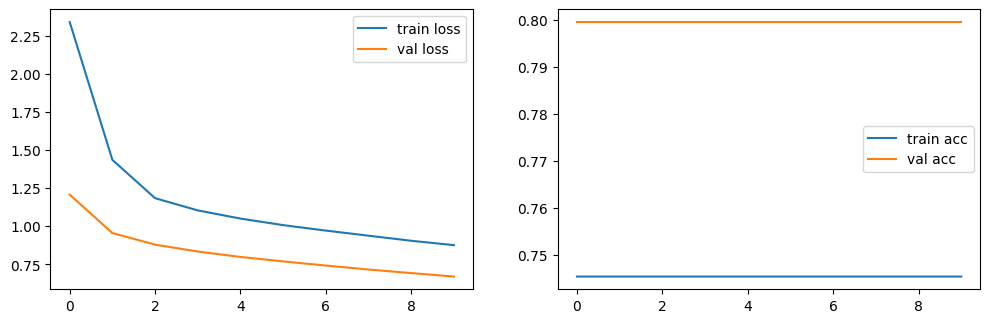

In [26]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from scipy.ndimage import binary_dilation

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
# Find optimal threshold
from sklearn.metrics import precision_recall_curve

y_pred = model.predict(x_val, verbose=0)
y_pred_prob = tf.nn.sigmoid(y_pred).numpy().flatten()
y_val_flat = y_val.flatten()

precision, recall, thresholds = precision_recall_curve(y_val_flat, y_pred_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_threshold:.4f}")

# Re-evaluate test set with optimal threshold
y_pred_test = model.predict(x_test, verbose=0)

y_pred_test_prob = tf.nn.sigmoid(y_pred_test).numpy().flatten()
y_pred_test_binary = (y_pred_test_prob > optimal_threshold).astype(int)
kernel = 100  
y_pred_smoothed = binary_dilation(y_pred_test_binary, iterations=kernel)
print(classification_report(y_test.flatten(), y_pred_smoothed, 
                          target_names=['Negative', 'Positive']))

/tmp/ipykernel_149084/1706663055.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),


TypeError: object of type 'numpy.bool' has no len()

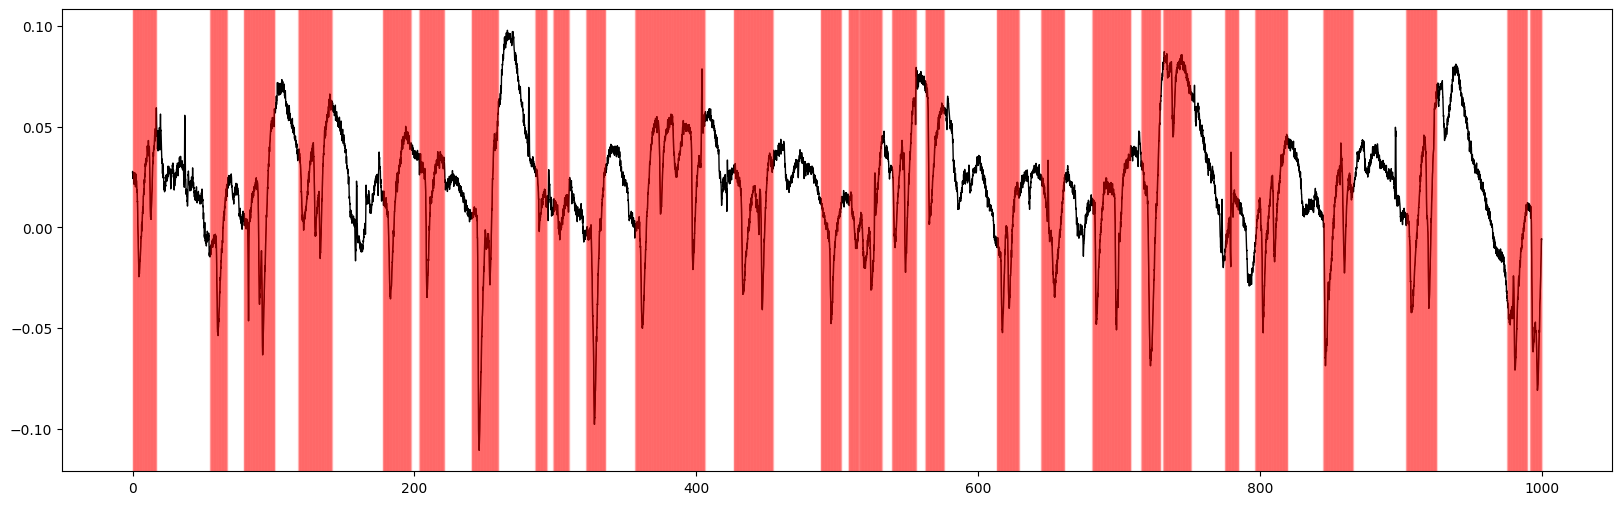

In [ ]:

def plot_multiple_examples(X_test, y_test, model, fs, optimal_threshold, 
                          n_examples=10, ylim_factor=1.5):
    """
    Plot predictions using optimal threshold with ground truth comparison
    """
    # Create output folder
    os.makedirs("Model_Predictions", exist_ok=True)

    for idx in range(min(n_examples, len(X_test))):
        # Get data
        audio = X_test[idx].squeeze()
        labels = y_test[idx].squeeze()

        # Raw model output for this example
        preds_raw = model.predict(X_test[idx:idx+1], verbose=0)[0].squeeze()

        # Apply sigmoid to get probabilities
        preds_prob = tf.nn.sigmoid(preds_raw).numpy()
        
        # Apply optimal threshold
        pred_mask = preds_prob > optimal_threshold

        # Create time axis in milliseconds
        time_ms = np.arange(len(audio)) / fs * 1000

        # Create figure
        fig, ax = plt.subplots(figsize=(20, 6))

        # Plot audio waveform
        ax.plot(time_ms, audio, color='black', linewidth=1, label='Audio Signal', zorder=1)

        # Highlight regions where label = 1 (ground truth events - RED)
        for i in range(len(labels)):
            if labels[i] == 1:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(1.0, 0.0, 0.0, 0.03), zorder=2, edgecolor='none')

        # Highlight regions where predicted mask == True (predicted events - GREEN)
        for i in range(len(pred_mask)):
            if pred_mask[i]:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(0.0, 1.0, 0.0, 0.03), zorder=3, edgecolor='none')

        # Set y-axis limits with more space (zoomed out)
        y_min, y_max = audio.min(), audio.max()
        y_range = y_max - y_min
        y_center = (y_max + y_min) / 2
        new_range = y_range * ylim_factor
        ax.set_ylim([y_center - new_range/2, y_center + new_range/2])

        # Get updated y-limits
        y_min_plot, y_max_plot = ax.get_ylim()
        y_mid = (y_min_plot + y_max_plot) / 2

        # Grid: major every 1 second (1000 ms)
        x_min, x_max = time_ms[0], time_ms[-1]
        major_start = int(np.ceil(x_min / 1000) * 1000)
        major_ticks = np.arange(major_start, x_max + 1, 1000)
        ax.set_xticks(major_ticks)

        # Grid: minor every 100 ms for better visibility
        minor_start = int(np.ceil(x_min / 100) * 100)
        minor_ticks = np.arange(minor_start, x_max + 1, 100)
        ax.set_xticks(minor_ticks, minor=True)

        ax.grid(which='major', color='black', linestyle='-', linewidth=1, alpha=0.7)
        ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.6, alpha=0.5)

        # Add time labels for minor ticks
        for x_pos in minor_ticks:
            if x_min < x_pos <= x_max:
                ax.text(x_pos, y_mid, f'{int(x_pos)}', rotation=90, 
                       verticalalignment='center', horizontalalignment='right', 
                       fontsize=7, color='grey', alpha=0.7)


        plt.tight_layout()

        # Save figure
        save_path = os.path.join("Model_Predictions", f"example_{idx+1}.png")
        plt.savefig(save_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {save_path}")

# Plot predictions with optimal threshold
plot_multiple_examples(x_test, y_test, model, fs, optimal_threshold, 
                       n_examples=3, ylim_factor=1.5)

/tmp/ipykernel_149084/661478307.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),


TypeError: object of type 'numpy.bool' has no len()

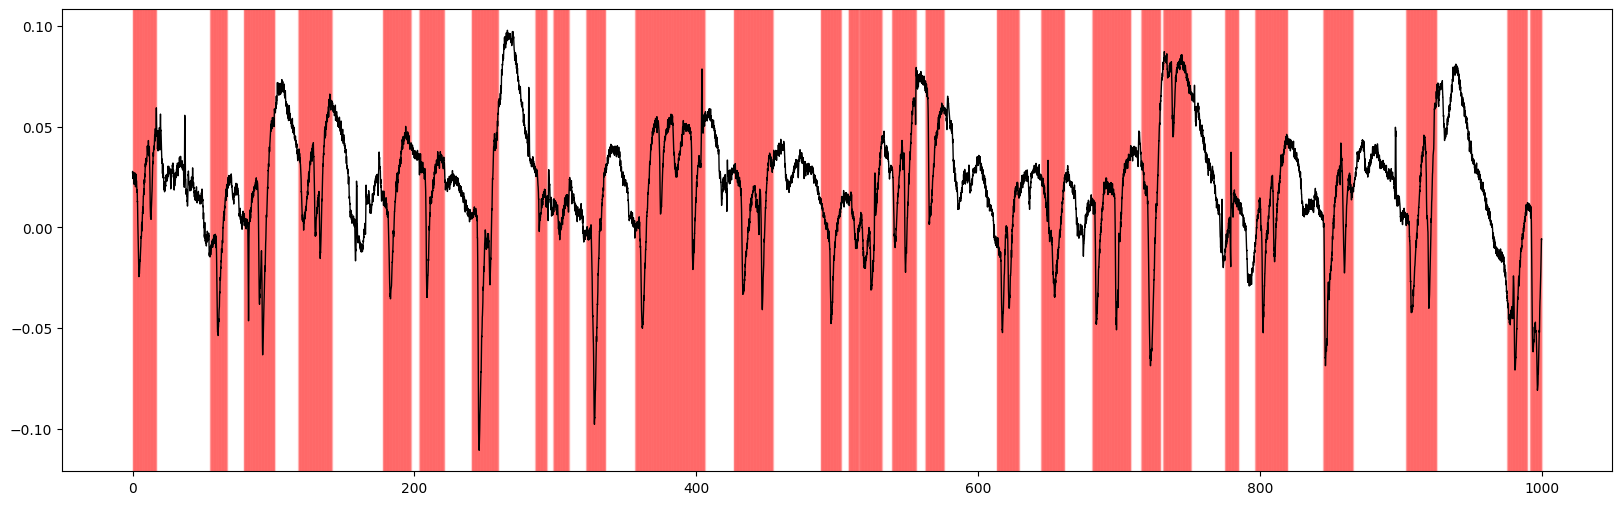

In [ ]:
def plot_multiple_examples(X_test, y_test, y_pred_mask, fs, 
                          n_examples=10, ylim_factor=1.5):
    os.makedirs("Model_Predictions", exist_ok=True)

    for idx in range(min(n_examples, len(X_test))):

        audio = X_test[idx].flatten()
        labels = y_test[idx].flatten()
        pred_mask = y_pred_mask[idx].flatten()

        time_ms = np.arange(len(audio)) / fs * 1000

        fig, ax = plt.subplots(figsize=(20, 6))
        ax.plot(time_ms, audio, color='black', linewidth=1)

        # ground truth
        for i in range(len(labels)):
            if labels[i] == 1:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),
                           color=(1,0,0,0.04), edgecolor='none')

        # predictions
        for i in range(len(pred_mask)):
            if pred_mask[i] == 1:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),
                           color=(0,1,0,0.04), edgecolor='none')

        plt.tight_layout()
        save_path = f"Model_Predictions/example_{idx+1}_dilated.png"
        plt.savefig(save_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {save_path}")


plot_multiple_examples(
    x_test,
    y_test,
    y_pred_smoothed,
    fs,
    n_examples=3
)

